# Experiment 6: Stability Across Random Initializations

### Objective
To investigate whether the observed generalization behavior remains stable across different random initializations of the same overparameterized neural network.

### Experimental Configuration

- Dataset: MNIST
- Width: 2048
- Parameters: 10,020,874
- Optimizer: Adam
- Learning rate: 0.001
- Batch size: 128
- Epochs: 30
- Random seeds: 42, 123, 456, 789, 1000
- Variable: Random initialization

Device: cuda
GPU: Tesla T4


100%|██████████| 9.91M/9.91M [00:00<00:00, 16.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 461kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.23MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.7MB/s]



Training samples: 60000
Test samples: 10000

Model width: 2048
Total parameters: 10020874

RUNNING SEED: 42
Epoch 10/30 | Train Acc: 99.39% | Test Acc: 97.88% | Gap: 1.51%
Epoch 20/30 | Train Acc: 99.76% | Test Acc: 98.22% | Gap: 1.54%
Epoch 30/30 | Train Acc: 99.69% | Test Acc: 97.99% | Gap: 1.70%

Seed 42 completed in 5.55 minutes
Final Train Accuracy: 99.69%
Final Test Accuracy: 97.99%
Generalization Gap: 1.70%
Parameter L2 Norm: 192.7313

RUNNING SEED: 123
Epoch 10/30 | Train Acc: 99.29% | Test Acc: 97.87% | Gap: 1.42%
Epoch 20/30 | Train Acc: 99.60% | Test Acc: 97.81% | Gap: 1.79%
Epoch 30/30 | Train Acc: 99.82% | Test Acc: 98.19% | Gap: 1.63%

Seed 123 completed in 5.52 minutes
Final Train Accuracy: 99.82%
Final Test Accuracy: 98.19%
Generalization Gap: 1.63%
Parameter L2 Norm: 192.9633

RUNNING SEED: 456
Epoch 10/30 | Train Acc: 99.35% | Test Acc: 97.86% | Gap: 1.49%
Epoch 20/30 | Train Acc: 99.66% | Test Acc: 98.02% | Gap: 1.64%
Epoch 30/30 | Train Acc: 99.79% | Test Acc: 98.2

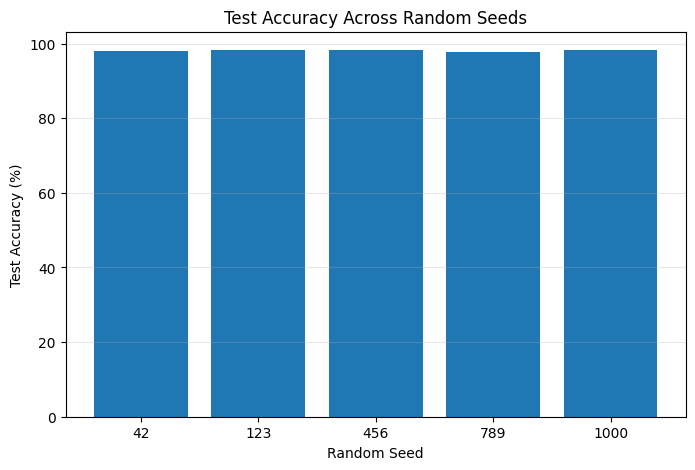

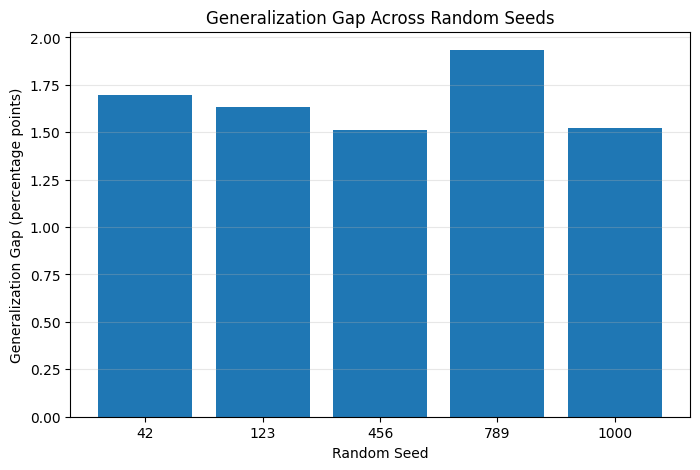

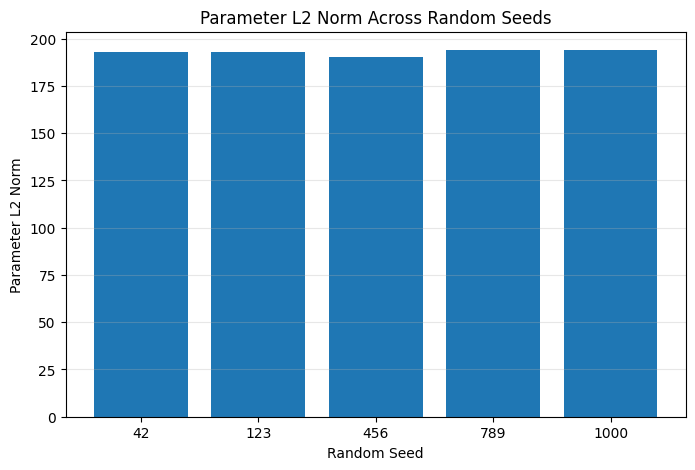

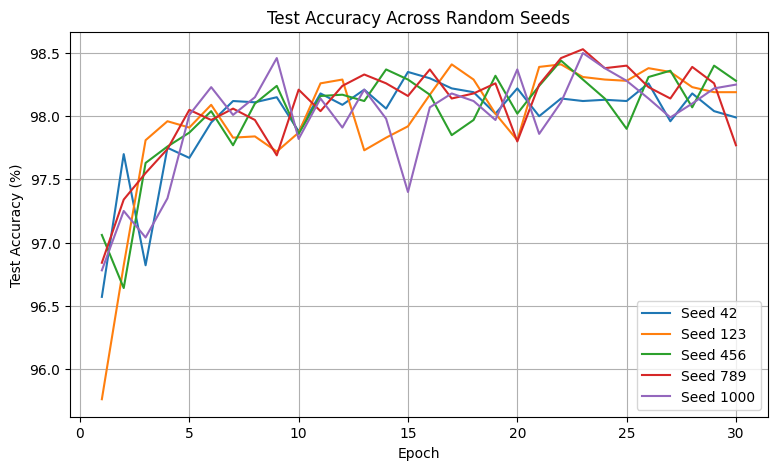

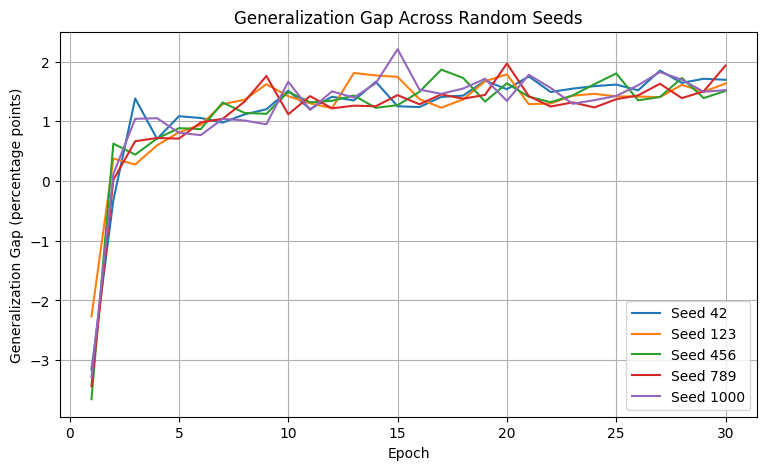



EXPERIMENT 6 SUMMARY
Test Accuracy: 98.10 ± 0.21%
Generalization Gap: 1.66 ± 0.17 percentage points
Parameter L2 Norm: 192.73 ± 1.55


In [ ]:
# ============================================================
# EXPERIMENT 6
# Stability Across Random Seeds
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import time


# ============================================================
# 1. DEVICE
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


# ============================================================
# 2. EXPERIMENT SETTINGS
# ============================================================

WIDTH = 2048
EPOCHS = 30
BATCH_SIZE = 128
LEARNING_RATE = 0.001

SEEDS = [42, 123, 456, 789, 1000]


# ============================================================
# 3. LOAD MNIST
# ============================================================

transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("\nTraining samples:", len(train_dataset))
print("Test samples:", len(test_dataset))


# ============================================================
# 4. MODEL
# ============================================================

class MLP(nn.Module):

    def __init__(self, width):

        super().__init__()

        self.network = nn.Sequential(

            nn.Flatten(),

            nn.Linear(28 * 28, width),
            nn.ReLU(),

            nn.Linear(width, width),
            nn.ReLU(),

            nn.Linear(width, width),
            nn.ReLU(),

            nn.Linear(width, 10)
        )

    def forward(self, x):

        return self.network(x)


# ============================================================
# 5. PARAMETER COUNT
# ============================================================

temp_model = MLP(WIDTH)

num_parameters = sum(
    p.numel()
    for p in temp_model.parameters()
)

del temp_model

print("\nModel width:", WIDTH)
print("Total parameters:", num_parameters)


# ============================================================
# 6. PARAMETER L2 NORM
# ============================================================

def calculate_l2_norm(model):

    squared_norm = 0.0

    for parameter in model.parameters():

        if parameter.requires_grad:

            squared_norm += torch.sum(
                parameter.detach() ** 2
            ).item()

    return squared_norm ** 0.5


# ============================================================
# 7. EVALUATION FUNCTION
# ============================================================

def evaluate(model, loader, criterion):

    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            total_loss += (
                loss.item() * images.size(0)
            )

            predictions = outputs.argmax(dim=1)

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)

    loss = total_loss / total

    accuracy = (
        100 * correct / total
    )

    return loss, accuracy


# ============================================================
# 8. TRAIN ONE RUN
# ============================================================

def run_experiment(seed):

    print("\n" + "=" * 65)
    print(f"RUNNING SEED: {seed}")
    print("=" * 65)

    # --------------------------------------------------------
    # Set seed
    # --------------------------------------------------------

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # --------------------------------------------------------
    # Data loaders
    # --------------------------------------------------------

    generator = torch.Generator()

    generator.manual_seed(seed)

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=generator
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    # --------------------------------------------------------
    # Model
    # --------------------------------------------------------

    model = MLP(WIDTH).to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE
    )

    start_time = time.time()

    history = []

    # ========================================================
    # TRAINING
    # ========================================================

    for epoch in range(EPOCHS):

        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            loss.backward()

            optimizer.step()

            running_loss += (
                loss.item() * images.size(0)
            )

            predictions = outputs.argmax(dim=1)

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)

        train_loss = running_loss / total

        train_accuracy = (
            100 * correct / total
        )

        # ----------------------------------------------------
        # Evaluation
        # ----------------------------------------------------

        test_loss, test_accuracy = evaluate(
            model,
            test_loader,
            criterion
        )

        gap = (
            train_accuracy -
            test_accuracy
        )

        history.append({

            "epoch": epoch + 1,

            "train_loss": train_loss,

            "train_accuracy": train_accuracy,

            "test_loss": test_loss,

            "test_accuracy": test_accuracy,

            "generalization_gap": gap
        })

        if (epoch + 1) % 10 == 0:

            print(
                f"Epoch {epoch+1:2d}/{EPOCHS} | "
                f"Train Acc: {train_accuracy:.2f}% | "
                f"Test Acc: {test_accuracy:.2f}% | "
                f"Gap: {gap:.2f}%"
            )

    # ========================================================
    # FINAL RESULTS
    # ========================================================

    runtime = time.time() - start_time

    final_train_loss = history[-1]["train_loss"]
    final_train_accuracy = history[-1]["train_accuracy"]

    final_test_loss = history[-1]["test_loss"]
    final_test_accuracy = history[-1]["test_accuracy"]

    final_gap = history[-1]["generalization_gap"]

    l2_norm = calculate_l2_norm(model)

    print(
        f"\nSeed {seed} completed "
        f"in {runtime / 60:.2f} minutes"
    )

    print(
        f"Final Train Accuracy: "
        f"{final_train_accuracy:.2f}%"
    )

    print(
        f"Final Test Accuracy: "
        f"{final_test_accuracy:.2f}%"
    )

    print(
        f"Generalization Gap: "
        f"{final_gap:.2f}%"
    )

    print(
        f"Parameter L2 Norm: "
        f"{l2_norm:.4f}"
    )

    result = {

        "Seed": seed,

        "Train Loss": final_train_loss,

        "Train Accuracy": final_train_accuracy,

        "Test Loss": final_test_loss,

        "Test Accuracy": final_test_accuracy,

        "Generalization Gap": final_gap,

        "L2 Norm": l2_norm,

        "Training Time (min)": runtime / 60
    }

    return model, history, result


# ============================================================
# 9. RUN ALL SEEDS
# ============================================================

results = []

all_histories = {}

for seed in SEEDS:

    model, history, result = run_experiment(seed)

    results.append(result)

    all_histories[seed] = history

    # Free GPU memory before next run
    del model

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


# ============================================================
# 10. RESULTS TABLE
# ============================================================

results_df = pd.DataFrame(results)

print("\n")
print("=" * 95)
print("FINAL RESULTS FOR ALL RANDOM SEEDS")
print("=" * 95)

print(
    results_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# ============================================================
# 11. MEAN AND STANDARD DEVIATION
# ============================================================

metrics = [
    "Train Accuracy",
    "Test Accuracy",
    "Generalization Gap",
    "L2 Norm"
]

summary = pd.DataFrame({

    "Mean": results_df[metrics].mean(),

    "Std Dev": results_df[metrics].std(),

    "Minimum": results_df[metrics].min(),

    "Maximum": results_df[metrics].max()
})


print("\n")
print("=" * 80)
print("MEAN ± STANDARD DEVIATION")
print("=" * 80)

print(
    summary.to_string(
        float_format=lambda x: f"{x:.4f}"
    )
)


# ============================================================
# 12. TEST ACCURACY ACROSS SEEDS
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    results_df["Seed"].astype(str),
    results_df["Test Accuracy"]
)

plt.xlabel("Random Seed")
plt.ylabel("Test Accuracy (%)")
plt.title("Test Accuracy Across Random Seeds")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()


# ============================================================
# 13. GENERALIZATION GAP ACROSS SEEDS
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    results_df["Seed"].astype(str),
    results_df["Generalization Gap"]
)

plt.xlabel("Random Seed")
plt.ylabel("Generalization Gap (percentage points)")
plt.title("Generalization Gap Across Random Seeds")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()


# ============================================================
# 14. L2 NORM ACROSS SEEDS
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    results_df["Seed"].astype(str),
    results_df["L2 Norm"]
)

plt.xlabel("Random Seed")
plt.ylabel("Parameter L2 Norm")
plt.title("Parameter L2 Norm Across Random Seeds")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()


# ============================================================
# 15. TEST ACCURACY DURING TRAINING
# ============================================================

plt.figure(figsize=(9, 5))

for seed in SEEDS:

    history_df = pd.DataFrame(
        all_histories[seed]
    )

    plt.plot(
        history_df["epoch"],
        history_df["test_accuracy"],
        label=f"Seed {seed}"
    )

plt.xlabel("Epoch")
plt.ylabel("Test Accuracy (%)")
plt.title("Test Accuracy Across Random Seeds")
plt.legend()

plt.grid(True)

plt.show()


# ============================================================
# 16. GENERALIZATION GAP DURING TRAINING
# ============================================================

plt.figure(figsize=(9, 5))

for seed in SEEDS:

    history_df = pd.DataFrame(
        all_histories[seed]
    )

    plt.plot(
        history_df["epoch"],
        history_df["generalization_gap"],
        label=f"Seed {seed}"
    )

plt.xlabel("Epoch")
plt.ylabel("Generalization Gap (percentage points)")
plt.title("Generalization Gap Across Random Seeds")
plt.legend()

plt.grid(True)

plt.show()


# ============================================================
# 17. FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 80)
print("EXPERIMENT 6 SUMMARY")
print("=" * 80)

print(
    f"Test Accuracy: "
    f"{summary.loc['Test Accuracy', 'Mean']:.2f} "
    f"± "
    f"{summary.loc['Test Accuracy', 'Std Dev']:.2f}%"
)

print(
    f"Generalization Gap: "
    f"{summary.loc['Generalization Gap', 'Mean']:.2f} "
    f"± "
    f"{summary.loc['Generalization Gap', 'Std Dev']:.2f} "
    f"percentage points"
)

print(
    f"Parameter L2 Norm: "
    f"{summary.loc['L2 Norm', 'Mean']:.2f} "
    f"± "
    f"{summary.loc['L2 Norm', 'Std Dev']:.2f}"
)

### Conclusion

Across five random initializations, the model showed relatively small variation in training accuracy, test accuracy, generalization gap, and parameter norm.

Thus, under the tested conditions, the observed generalization behavior was reasonably stable across different random initializations.